In [1]:
import torch
from score_models import NCSNpp
import sys
from torch.func import jacrev, jacfwd, vjp, vmap
from torch.autograd import grad
import numpy as np
sys.path.append("../scripts/")
from astropy.io import fits
from astropy.coordinates import SkyCoord
from torch.func import jvp
from astropy import units
from forward_model import make_forward_model, make_wcs

# Check that we can recover A easily with jacrev or jacfwd

In [2]:
n = 1000
m = 50
A = torch.randn([n, m]) * 1e-2

def f(x):
    return A @ x

# This is the way I would get A without spending the effort of constructing it by hand
x = torch.randn(m)
# jac = jacfwd(f)(x)
jac = jacrev(f)(x)
torch.allclose(A, jac)

True

# Some preliminary inverstigations

In [3]:
sigma_min = 1e-3
sigma_max = 10
B = 2

right_matmul = vmap(torch.matmul, in_dims=(None, 0))
left_matmul = vmap(torch.matmul, in_dims=(0, None))
matmul = vmap(torch.matmul)
inverse = vmap(torch.linalg.inv)

def precision(t):
    return inverse(covariance(t))

def covariance(t):    
    Sigma = torch.eye(m).view(1, m, m) * sigma(t).view(-1, 1, 1)**2
    left = right_matmul(A, Sigma)
    cov = left_matmul(left, A.T)
    return cov

def sigma(t):
    return sigma_min * (sigma_max / sigma_min)**t.view(-1, 1)

# In effect, this is the correct score for the problem given our perturbation kernel
def kernel_score(t):
    z = torch.randn([B, m])
    z_t = right_matmul(A, z * sigma(t))
    return -matmul(z_t, precision(t))

# This kernel will be prohibitive to compute. For example, even if we consider patches of 16x16
print(f"n={16**2}")
# for super sampler, we generally have m > n, e.g. m=n*4^2
print(f"m={16**3}")
# Which requires manipulating A of size approx 10^6 (for a single batch element in the training)
print(f"m times n = {16**5}")



n=256
m=4096
m times n = 1048576


This will tremendously slow down training, for very little gain compared to my wrong baseline which already works well. 

In the end, all I need is the correct scale for the score so that it compares correctly with the prior. 
We can make the following approximation:

Suppose that we approximate the precision with it's diagonal to only keep the correct scaling, 
Suppose further that we make uniform. Then we only need to estimate
$$
    \mathbb{E}_i[\mathrm{diag}[A \Sigma A^T]_i]
$$
Which is the expected value of the covariance matrix diagonal elements. Let's try this with our random matrix


In [4]:
torch.diag(covariance(torch.ones([1, 1])).squeeze()).mean() / sigma(torch.ones([1, 1])).squeeze()

tensor(0.0498)

In [5]:
exp = []
for t in np.linspace(0, 1, 10):
    _t = torch.tensor(t).view(-1, 1).float()
    exp.append(torch.diag(covariance(_t).squeeze()) / sigma(_t).squeeze()**2)

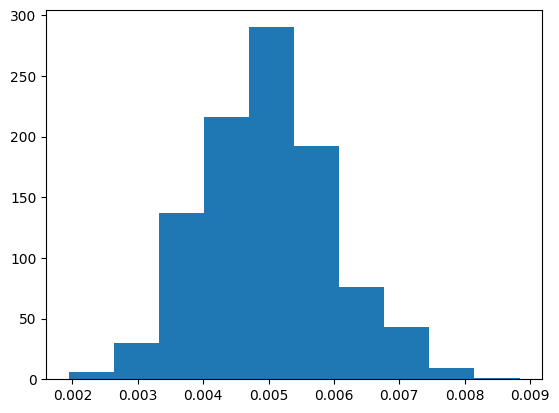

In [6]:
# So there is a constant factor at play for a specific matrix A!
exp = torch.stack(exp)
plt.hist(exp.mean(dim=0));

The above will not work. Let's investigate a more principled approach

In [7]:
# factor = torch.mean(exp) * n**(-1/2)
# B = 256

# def kernel_score_approx(t):
#     z = torch.randn([B, m])
#     z_t = right_matmul(A, z * sigma(t))
#     return -z_t / sigma(t)**2 / factor

# Locality and uniformity approximation

If the forward model only correlate local structures in a uniform way similar to what a convolution would do,then 
we can approximate $C = A \Sigma A^T$ as a circulant matrix. In the following cells we develop the intuition 
for how this approximation will help us evaluate the score during training much more easily. 

We will test how much this is true, but this approximation will serve us in recovering the right score for training. 

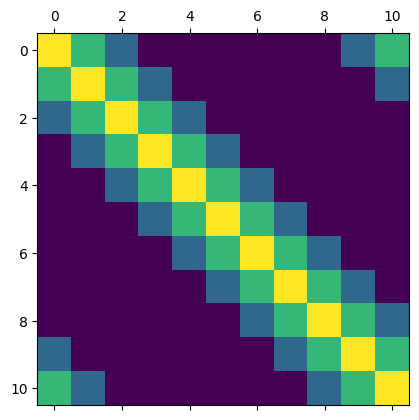

In [8]:
def construct_circulant(row):
    # append rows by applying a cyclic shift
    C = np.zeros([row.size, row.size])
    for i in range(row.size):
        C[i] = np.roll(row, shift=i)
    return C

# h = np.array([1, 3, 1])
h = np.array([0, 0, 0, 1, 2, 3, 2, 1, 0, 0, 0])

# kernel is centered, account for this by shifting center to first element of the row 
row = np.roll(h, shift=h.size//2 + 1*(h.size%2))
C = torch.tensor(construct_circulant(row)).float()
n = h.size

plt.matshow(C)

In [9]:
def log_prob(x, C):
    return -0.5 * x.T @ C.inverse() @ x

def analytic_score(x, C):
    return -x.T @ C.inverse()

x = torch.randn(n, requires_grad=True)
# x = torch.ones(n, requires_grad=True)

score_analytic = analytic_score(x, C)
print('Analytic score:', score_analytic)

score_autograd = grad(log_prob(x, C), x)[0]
print('Autograd score:', score_autograd)

Lambda = torch.fft.fft(C[0])  # DFT of the first row of C
# print(Lambda)
Lambda_inv = torch.zeros_like(Lambda)
Lambda_inv[Lambda != 0.] = 1/Lambda[Lambda != 0.]
# Lambda_inv[Lambda == 0.] = 1/1e-7

def fft_log_prob(x):
    # Transform x into Fourier space
    x_prime = torch.fft.fft(x) / x.shape[0]**(1/2)
    log_prob = -0.5 * torch.sum(x_prime.conj() * Lambda_inv * x_prime)
    return torch.real(log_prob)

def fft_score(x):
    x_prime = torch.fft.fft(x)
    score_prime = x_prime * Lambda_inv
    score = -torch.fft.ifft(score_prime).real
    return score

score_fft = grad(fft_log_prob(x), x)[0]
score_fft_a = fft_score(x)

print('FFT score:', score_fft)
print('FFT score a:', score_fft_a)

assert torch.allclose(score_fft, score_analytic)
assert torch.allclose(score_fft_a, score_analytic)
assert torch.allclose(score_autograd, score_analytic)

Analytic score: tensor([ 7.0947, -6.6848,  1.1419,  6.8673, -9.0514,  3.4585,  4.0307, -6.7267,
         5.3578, -1.8904, -2.8979], grad_fn=<SqueezeBackward4>)
Autograd score: tensor([ 7.0947, -6.6848,  1.1419,  6.8673, -9.0514,  3.4585,  4.0307, -6.7267,
         5.3578, -1.8904, -2.8979])
FFT score: tensor([ 7.0947, -6.6848,  1.1419,  6.8673, -9.0514,  3.4585,  4.0307, -6.7267,
         5.3578, -1.8904, -2.8979])
FFT score a: tensor([ 7.0947, -6.6848,  1.1419,  6.8673, -9.0514,  3.4585,  4.0307, -6.7267,
         5.3578, -1.8904, -2.8979], grad_fn=<NegBackward0>)


/tmp/ipykernel_6803/425079264.py:5: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3571.)
  return -x.T @ C.inverse()


# $C = AA^T$, where $A$ is the circulant matrix

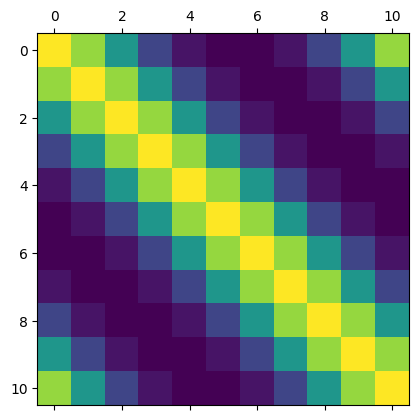

In [10]:
def construct_circulant(row):
    # append rows by applying a cyclic shift
    C = np.zeros([row.size, row.size])
    for i in range(row.size):
        C[i] = np.roll(row, shift=i)
    return C

# h = np.array([1, 3, 1])
h = np.array([0, 0, 0, 1, 2, 3, 2, 1, 0, 0, 0])

# kernel is centered, account for this by shifting center to first element of the row 
row = np.roll(h, shift=h.size//2 + 1*(h.size%2))
A = torch.tensor(construct_circulant(row)).float()
C = A @ A.T
n = h.size

plt.matshow(C)

In [11]:
def log_prob(x, C):
    return -0.5 * x.T @ C.inverse() @ x

def analytic_score(x, C):
    return -x.T @ C.inverse()

x = torch.randn(n, requires_grad=True)
# x = torch.ones(n, requires_grad=True)

score_analytic = analytic_score(x, C)
print('Analytic score:', score_analytic)

score_autograd = grad(log_prob(x, C), x)[0]
print('Autograd score:', score_autograd)

# Lambda = torch.fft.fft(C[0])  # DFT of the first row of C
# # print(Lambda)
# Lambda_inv = torch.zeros_like(Lambda)
# Lambda_inv[Lambda != 0.] = 1/Lambda[Lambda != 0.]
# # Lambda_inv[Lambda == 0.] = 1/1e-7

# Check that we can compute the precision from A
Lambda = torch.fft.fft(A[0])  # DFT of the first row of A
# print(Lambda)
Lambda_inv = torch.zeros_like(Lambda)
Lambda_inv[Lambda != 0.] = 1/Lambda[Lambda != 0.] / Lambda[Lambda != 0.].conj() # account for the A^T matrix

# Lambda_inv[Lambda == 0.] = 1/1e-7


def fft_log_prob(x):
    # Transform x into Fourier space
    x_prime = torch.fft.fft(x) / x.shape[0]**(1/2)
    log_prob = -0.5 * torch.sum(x_prime.conj() * Lambda_inv * x_prime)
    return torch.real(log_prob)

def fft_score(x):
    x_prime = torch.fft.fft(x)
    score_prime = x_prime * Lambda_inv
    score = -torch.fft.ifft(score_prime).real
    return score

score_fft = grad(fft_log_prob(x), x)[0]
score_fft_a = fft_score(x)

print('FFT score:', score_fft)
print('FFT score a:', score_fft_a)

assert torch.allclose(score_fft, score_analytic, rtol=1e-3)
assert torch.allclose(score_fft_a, score_analytic, rtol=1e-3)
assert torch.allclose(score_autograd, score_analytic, rtol=1e-3)

Analytic score: tensor([ -51.6764,  107.0287,  -88.6475,    8.7437,   77.6211, -110.2889,
          66.0816,   24.1600,  -97.6263,  103.8874,  -39.3428],
       grad_fn=<SqueezeBackward4>)
Autograd score: tensor([ -51.6758,  107.0285,  -88.6479,    8.7445,   77.6205, -110.2890,
          66.0822,   24.1594,  -97.6260,  103.8876,  -39.3433])
FFT score: tensor([ -51.6713,  107.0232,  -88.6453,    8.7464,   77.6152, -110.2838,
          66.0810,   24.1558,  -97.6202,  103.8837,  -39.3439])
FFT score a: tensor([ -51.6713,  107.0232,  -88.6453,    8.7464,   77.6152, -110.2839,
          66.0810,   24.1558,  -97.6202,  103.8837,  -39.3439],
       grad_fn=<NegBackward0>)


## 2D circulant

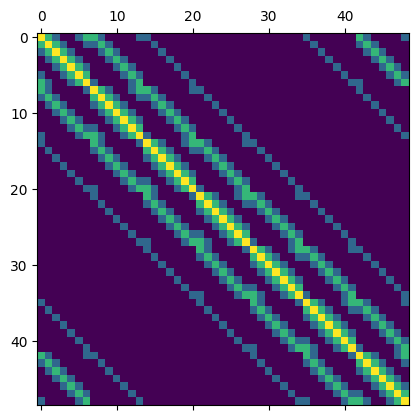

In [12]:
def construct_super_row(kernel):
    N = kernel.shape[0]
    super_row = np.zeros((N, N*N))
    # Roll the rows to put center on the first element of the kernel
    kernel = np.roll(kernel, shift=kernel.shape[1]//2 + 1*(kernel.shape[1]%2), axis=1)
    # Finally, move the central row on top
    kernel = np.roll(kernel, shift=kernel.shape[0]//2 + 1*(kernel.shape[0]%2), axis=0)
    for i in range(N):
        # The ith row of the kernel forms the basis for the ith block
        row = kernel[i, :]
        # Construct the 1D circulant matrix for this block
        block = construct_circulant(row)
        # Insert the block into the super row
        super_row[:, i*N:(i+1)*N] = block
    return super_row

def super_roll(super_row, shift):
    N = super_row.shape[0]
    return np.roll(super_row, shift=N*shift, axis=1)

def construct_block_circulant(kernel):
    N, M = kernel.shape
    super_row = construct_super_row(kernel)
    C = np.zeros([N*M, N*M])
    for i in range(N):
        # stack rolled super rows (in analogy to circulant 1d)
        C[i*N:(i+1)*N] = super_roll(super_row, shift=i)
    return C

# h = np.array([[0, 1, 0],
#               [1, 3, 1],
#               [0, 1, 0]])

h = np.array([[0, 0, 0, 0, 0, 0, 0],
              [0, 0, 0, 1, 0, 0, 0],
              [0, 0, 1, 2, 1, 0, 0],
              [0, 1, 2, 3, 2, 1, 0],
              [0, 0, 1, 2, 1, 0, 0],
              [0, 0, 0, 1, 0, 0, 0],
              [0, 0, 0, 0, 0, 0, 0]
             ])

n, m = h.shape
C = torch.tensor(construct_block_circulant(h)).float()
plt.matshow(C)

In [13]:
def log_prob(x, C):
    return -0.5 * x.flatten().T @ C.inverse() @ x.flatten()

def analytic_score(x, C):
    return -x.flatten().T @ C.inverse()

x = torch.randn([n, m], requires_grad=True)
# x = torch.ones(n, requires_grad=True)

score_analytic = analytic_score(x, C)
print('Analytic score:', score_analytic)

score_autograd = grad(log_prob(x, C), x)[0]
print('Autograd score:', score_autograd)

# 2D FFT of the first block, which contains all the information of the C matrix (similar to first row of 1D circulant
Lambda = torch.fft.fft2(C.view(n, m, n, m)[0, 0])
Lambda_inv = torch.zeros_like(Lambda)
Lambda_inv[Lambda != 0.] = 1/Lambda[Lambda != 0.]
# Lambda_inv[Lambda == 0.] = 1/1e-7

def fft_log_prob(x):
    # Transform x into Fourier space
    x_prime = torch.fft.fft2(x) / (n*m)**(1/2)
    log_prob = -0.5 * torch.sum(x_prime.conj() * Lambda_inv * x_prime)
    return torch.real(log_prob)

def fft_score(x):
    x_prime = torch.fft.fft2(x)
    score_prime = x_prime * Lambda_inv
    score = -torch.fft.ifft2(score_prime.view(n, m)).real
    return score

score_fft = grad(fft_log_prob(x), x)[0]
score_fft_a = fft_score(x)

print('FFT score:', score_fft)
print('FFT score a:', score_fft_a)


assert torch.allclose(score_fft.flatten(), score_analytic, atol=1e-5)
assert torch.allclose(score_fft_a.flatten(), score_analytic, atol=1e-5)
assert torch.allclose(score_autograd.flatten(), score_analytic, atol=1e-5)

Analytic score: tensor([-0.7784,  1.3509, -1.2327,  0.3783, -0.4970, -1.0655,  0.2304,  0.0867,
         0.3114,  0.0129, -0.3431,  0.7966,  0.4293, -0.1769,  0.3162, -1.2835,
         0.7421,  0.3426, -0.4849,  0.1294,  0.1227,  0.7284, -0.4160,  0.1022,
        -0.3553,  0.3533, -0.2725, -0.8778,  1.2549, -0.6405,  0.7316, -0.6361,
         0.0762, -0.0180,  0.5189, -1.7679,  0.0084,  0.0300,  0.5188,  0.5869,
         0.0134, -0.3790, -0.5679,  1.1246, -0.2412, -0.1786, -0.6194,  0.4040,
         1.3725], grad_fn=<SqueezeBackward4>)
Autograd score: tensor([[-0.7784,  1.3509, -1.2326,  0.3783, -0.4970, -1.0655,  0.2304],
        [ 0.0867,  0.3114,  0.0129, -0.3431,  0.7966,  0.4293, -0.1769],
        [ 0.3162, -1.2835,  0.7421,  0.3426, -0.4849,  0.1294,  0.1227],
        [ 0.7284, -0.4160,  0.1022, -0.3553,  0.3533, -0.2725, -0.8778],
        [ 1.2549, -0.6405,  0.7316, -0.6361,  0.0762, -0.0180,  0.5189],
        [-1.7679,  0.0084,  0.0300,  0.5188,  0.5869,  0.0134, -0.3790],
    

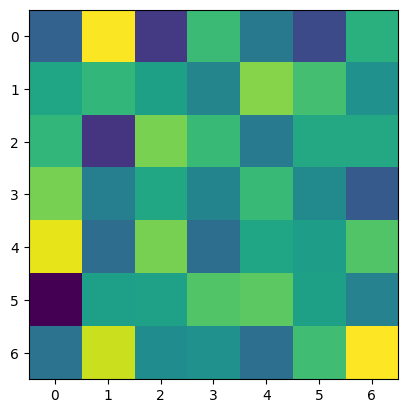

In [14]:
plt.imshow(score_analytic.view(7, 7).detach())

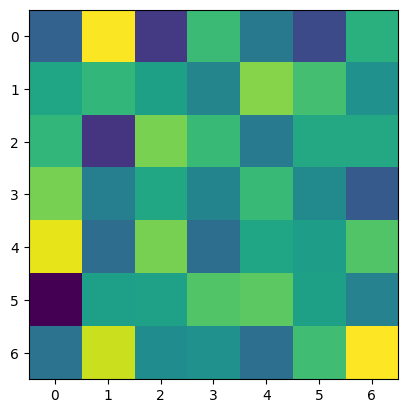

In [15]:
plt.imshow(score_fft)

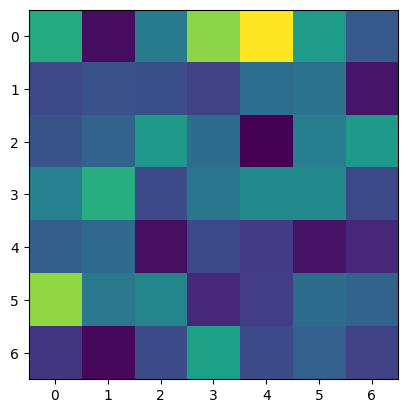

In [16]:
plt.imshow(x.detach())

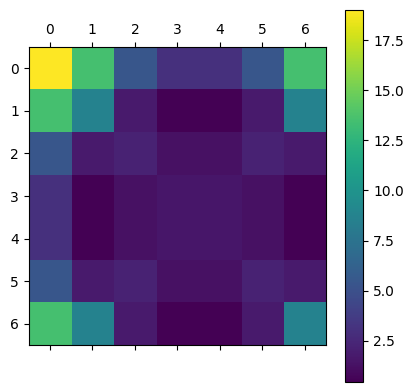

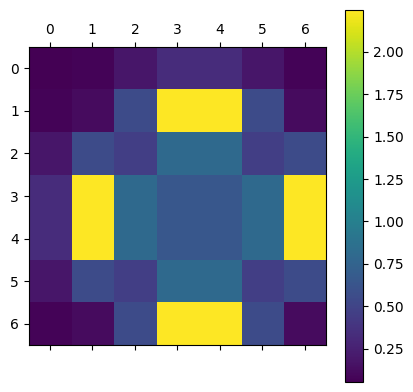

In [17]:
plt.matshow(Lambda.abs())
plt.colorbar()
plt.matshow(Lambda_inv.abs())
plt.colorbar()

# Quickly computing $\Lambda_t$

See Matern kernel? https://en.wikipedia.org/wiki/Mat%C3%A9rn_covariance_function

If $A$ can be approximated as a circulant matrix, then we can use the properties of circulant matrices to our advantage. One important property is that circulant matrices are diagonalized by a Fourier matrix. More concretely, if $A$ is circulant, then we can write it as:

$A = F \Lambda F^*$

where $F$ is a Fourier matrix, $\Lambda$ is a diagonal matrix, and $F^*$ is the conjugate transpose of $F$.

So to diagonalize $A$, you can apply the 2D Fast Fourier Transform (FFT) to the first row (or block) of $A$. This will give you $\Lambda$, the diagonal matrix in the Fourier domain.

If $\Sigma$ is diagonal and scales with $\sigma(t)$, then $A \Sigma A^T$ can be computed as $A (\sigma(t) I) A^T$ (where $I$ is the identity matrix), which simplifies to $\sigma(t) A A^T$. Now, using the fact that $A = F \Lambda F^*$, we can write this as $\sigma(t) F \Lambda F^* F \Lambda F^*$, which simplifies to $\sigma(t) F \Lambda^2 F^*$ because $F^* F = I$.

This means that you only need to compute $\Lambda$ once (by applying the 2D FFT to the first row of $A$). To get the $t$-dependent covariance matrix, you then simply square $\Lambda$, scale it by $\sigma(t)$, and then apply the inverse Fourier transform to get back into the spatial domain.

This should give you a fast method for computing the $t$-dependent covariance matrix. Note that this does require that $A$ can be well-approximated as a circulant matrix, so the accuracy of this method will depend on how good that approximation is. Also, note that this assumes that $\Sigma$ scales uniformly with $\sigma(t)$, as in your problem description. If the scaling of $\Sigma$ is non-uniform, then this method will need to be adjusted.

In [576]:
# Now we test this idea on the actual forward model
coord = SkyCoord(ra=10*units.deg, dec=20*units.deg)
observation_pixels = 64
model_pixels = 256
observation_pixel_size = 0.05
model_pixel_size = 0.025

wcs = make_wcs(coord, orientation=0, pixels=observation_pixels, pixel_size=observation_pixel_size * units.arcsec)
wcs_list = [wcs]
with fits.open("../data/F814w_WFC3UV_psf.fits") as data:
    psf = data["PRIMARY"].data.astype(np.float32)[None]
forward_model = make_forward_model(
        psf, 
        wcs_list, 
        super_sampling_factor=4,
        model_pixels=model_pixels,
        model_pixel_size=model_pixel_size * units.arcsec
        )

x = torch.randn(size=[1, 1, model_pixels, model_pixels])
# A = jacrev(forward_model)(x)
# print(A.shape)
# A = A.view(observation_pixels**2, model_pixels**2)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 10.00001478024554  19.99998611111051  
CRPIX : 63.5  63.5  
PC1_1 PC1_2  : 6.94444444444444e-06  0.0  
PC2_1 PC2_2  : 0.0  -6.9444444444444e-06  
CDELT : 1.0  1.0  
NAXIS : 128  128


In [577]:
# plt.figure(figsize=(32, 16))
# plt.matshow(A, cmap="magma", vmax=A.max(), vmin=A.min())
# plt.colorbar()
# plt.figure(figsize=(32, 16))
# plt.matshow(A[:observation_pixels, :model_pixels], cmap="magma", vmax=A.max(), vmin=A.min())
# plt.colorbar()
# plt.figure(figsize=(32, 16))
# plt.matshow(A[:2*observation_pixels, :2*model_pixels], cmap="magma", vmax=A.max(), vmin=A.min())
# plt.colorbar()
# plt.figure(figsize=(32, 16))
# plt.matshow(A[:3*observation_pixels, :3*model_pixels], cmap="magma", vmax=A.max(), vmin=A.min())
# plt.colorbar()
# plt.figure(figsize=(32, 16))
# plt.matshow(A[:6*observation_pixels, :6*model_pixels], cmap="magma", vmax=A.max(), vmin=A.min())
# plt.colorbar()
# plt.figure(figsize=(32, 16))
# plt.matshow(A[:12*observation_pixels, :6*model_pixels], cmap="magma", vmax=A.max(), vmin=A.min())
# plt.colorbar()
# # plt.colorbar()

tensor(0.2500)


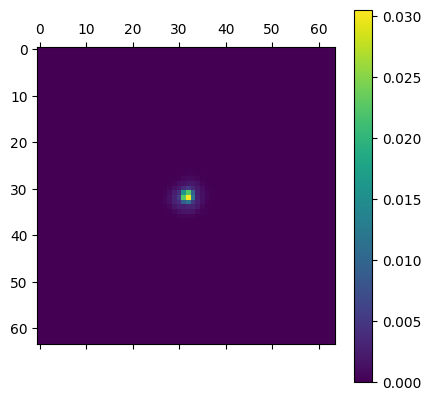

In [578]:
x = torch.randn(size=[1, 1, model_pixels, model_pixels])
v = torch.zeros_like(x)
v[0, 0, model_pixels//2, model_pixels//2] = 1
_, kernel = jvp(forward_model, (x, ), (v, ))
kernel = kernel[0, 0]

print(kernel.sum())
plt.matshow(kernel)
plt.colorbar()

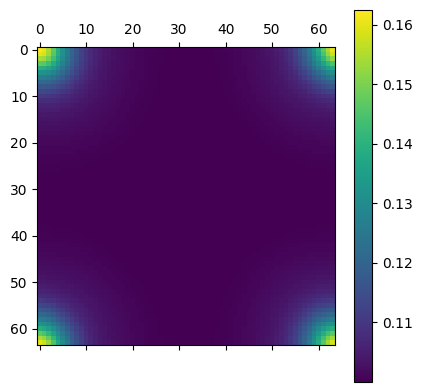

In [644]:
beta = 1e-1
Lambda = torch.abs(torch.fft.fft2(kernel))**2 + beta
Lambda_inv = 1/Lambda
plt.matshow(Lambda.abs())
plt.colorbar()

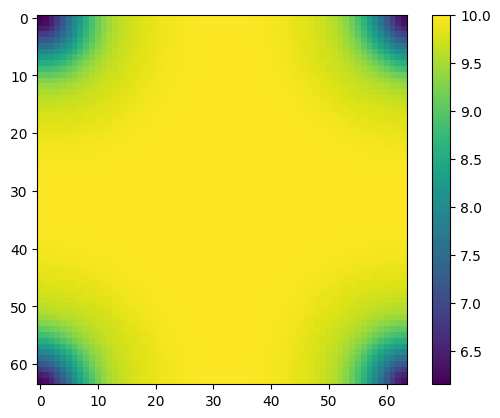

In [645]:
plt.imshow(Lambda_inv)
plt.colorbar()

# Final repeat the 2d kernel test, make sure our regularisation works

In [646]:
n = observation_pixels
m = model_pixels

A_eff = torch.tensor(construct_block_circulant(kernel.numpy())).float()
C = A_eff @ A_eff.T + beta * torch.eye(n**2)

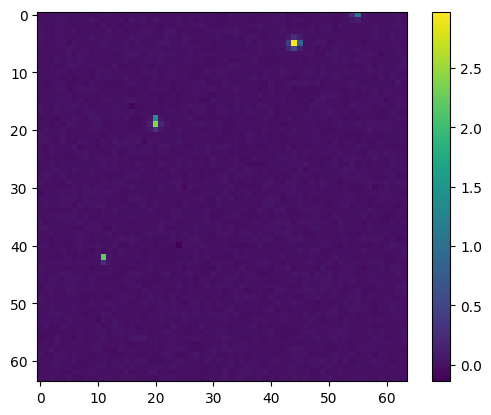

In [647]:
noise = np.load("../data/connor_targets_flat_fields_noise_cutouts.npy")[101]
plt.imshow(noise)
plt.colorbar()

In [648]:
n = observation_pixels
m = model_pixels
x = forward_model(torch.randn([m, m])[None, None]).float()[0, 0] #+ torch.tensor(noise).float()
x.requires_grad = True

def log_prob(x, C):
    return -0.5 * x.flatten().T @ C.inverse() @ x.flatten()

def analytic_score(x, C):
    return -x.flatten().T @ C.inverse()

score_analytic = analytic_score(x, C)
print('Analytic score:', score_analytic)

score_autograd = grad(log_prob(x, C), x)[0]
print('Autograd score:', score_autograd)

def fft_log_prob(x):
    # Transform x into Fourier space
    x_prime = torch.fft.fft2(x) / (n**2)**(1/2)
    log_prob = -0.5 * torch.sum(x_prime.conj() * Lambda_inv * x_prime)
    return torch.real(log_prob)

def fft_score(x):
    x_prime = torch.fft.fft2(x)
    score_prime = x_prime * Lambda_inv
    score = -torch.fft.ifft2(score_prime.view(n, n)).real
    return score

score_fft = grad(fft_log_prob(x), x)[0]
score_fft_a = fft_score(x)

print('FFT score:', score_fft)
print('FFT score a:', score_fft_a)

assert torch.allclose(score_fft.flatten(), score_analytic, atol=1e-5)
assert torch.allclose(score_fft_a.flatten(), score_analytic, atol=1e-5)
assert torch.allclose(score_autograd.flatten(), score_analytic, atol=1e-5)

Analytic score: tensor([0.4814, 1.0745, 0.9545,  ..., 0.6484, 1.1472, 1.1377],
       grad_fn=<SqueezeBackward4>)
Autograd score: tensor([[ 0.4814,  1.0745,  0.9545,  ..., -0.0501,  0.2042, -0.2028],
        [ 0.2025,  0.9410,  1.4354,  ...,  1.2683,  1.4269,  0.3955],
        [ 1.0672,  1.5713,  1.4000,  ...,  0.7984,  0.9111,  0.3723],
        ...,
        [-0.5134, -0.9486, -0.0642,  ...,  2.4913,  2.9987,  1.4591],
        [-1.2956, -1.7720, -1.1715,  ...,  1.6071,  2.1898,  1.4482],
        [-1.4601, -1.8089, -1.7790,  ...,  0.6484,  1.1472,  1.1377]])
FFT score: tensor([[ 0.4814,  1.0745,  0.9545,  ..., -0.0501,  0.2042, -0.2028],
        [ 0.2025,  0.9410,  1.4354,  ...,  1.2683,  1.4269,  0.3955],
        [ 1.0672,  1.5713,  1.4000,  ...,  0.7984,  0.9111,  0.3723],
        ...,
        [-0.5134, -0.9486, -0.0642,  ...,  2.4913,  2.9987,  1.4591],
        [-1.2956, -1.7720, -1.1715,  ...,  1.6071,  2.1898,  1.4482],
        [-1.4601, -1.8089, -1.7790,  ...,  0.6484,  1.1472,  1

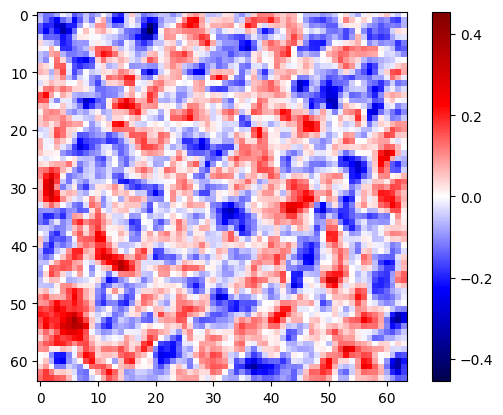

In [649]:
plt.imshow(x.detach(), cmap="seismic", norm=plt.cm.colors.CenteredNorm())
plt.colorbar()

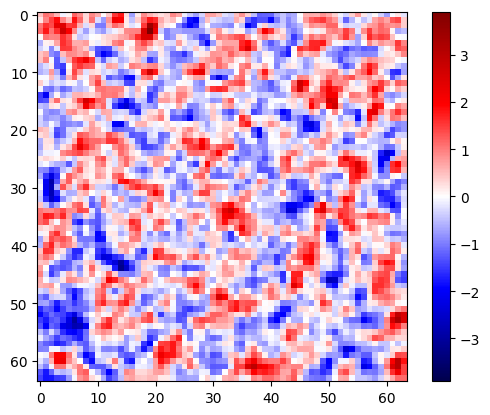

In [650]:
plt.imshow(score_fft, cmap="seismic", norm=plt.cm.colors.CenteredNorm())
plt.colorbar()

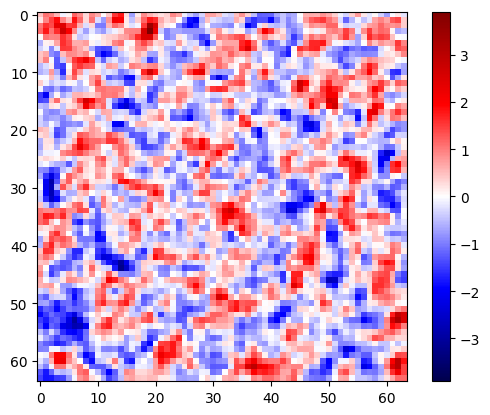

In [651]:
plt.imshow(score_analytic.detach().view(64, 64), cmap="seismic", norm=plt.cm.colors.CenteredNorm())
plt.colorbar()

In [652]:
print(torch.norm(score_fft))

tensor(59.2679)


In [653]:
print(torch.norm(score_analytic))

tensor(59.2680, grad_fn=<LinalgVectorNormBackward0>)


# F105W filters

In [533]:
# Now we test this idea on the actual forward model
coord = SkyCoord(ra=10*units.deg, dec=20*units.deg)
observation_pixels = 32
model_pixels = 256
observation_pixel_size = 0.13
model_pixel_size = 0.13 / 8 

wcs = make_wcs(coord, orientation=0, pixels=observation_pixels, pixel_size=observation_pixel_size * units.arcsec)
wcs_list = [wcs]
with fits.open("../data/F105w_WFC3IR_psf.fits") as data:
    psf = data["PRIMARY"].data.astype(np.float32)[None]
forward_model = make_forward_model(
        psf, 
        wcs_list, 
        super_sampling_factor=4,
        model_pixels=model_pixels,
        model_pixel_size=model_pixel_size * units.arcsec
        )

x = torch.randn(size=[1, 1, model_pixels, model_pixels])
v = torch.zeros_like(x)
v[0, 0, model_pixels//2, model_pixels//2] = 1
_, kernel = jvp(forward_model, (x, ), (v, ))
kernel = kernel[0, 0]

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 10.00003842863297  19.99996388888476  
CRPIX : 127.5  127.5  
PC1_1 PC1_2  : 4.51388888888888e-06  0.0  
PC2_1 PC2_2  : 0.0  -4.5138888888888e-06  
CDELT : 1.0  1.0  
NAXIS : 256  256


tensor(0.0156)


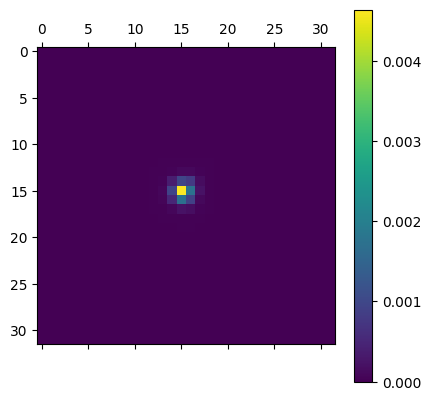

In [534]:
print(kernel.sum())
plt.matshow(kernel)
plt.colorbar()

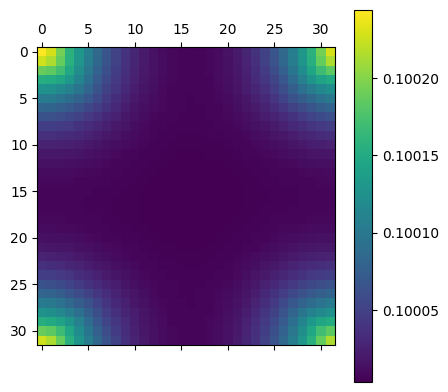

In [544]:
# Beta is a form of ridge regularisation
beta = 1e-1
Lambda = torch.abs(torch.fft.fft2(kernel))**2 + beta
Lambda_inv = 1 / Lambda
plt.matshow(Lambda.abs())
plt.colorbar()

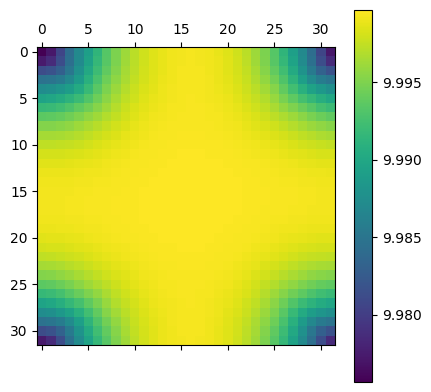

In [545]:
plt.matshow(Lambda_inv)
plt.colorbar()

In [546]:
n = observation_pixels
m = model_pixels

A_eff = torch.tensor(construct_block_circulant(kernel.numpy())).float()
C = A_eff @ A_eff.T + beta * torch.eye(n**2)

In [547]:
n = observation_pixels
m = model_pixels
x = forward_model(torch.randn([m, m])[None, None]).float()[0, 0]
x.requires_grad = True

def log_prob(x, C):
    return -0.5 * x.flatten().T @ C.inverse() @ x.flatten()

def analytic_score(x, C):
    return -x.flatten().T @ C.inverse()

score_analytic = analytic_score(x, C)
print('Analytic score:', score_analytic)

score_autograd = grad(log_prob(x, C), x)[0]
print('Autograd score:', score_autograd)

def fft_log_prob(x):
    # Transform x into Fourier space
    x_prime = torch.fft.fft2(x) / (n**2)**(1/2)
    log_prob = -0.5 * torch.sum(x_prime.conj() * Lambda_inv * x_prime)
    return torch.real(log_prob)

def fft_score(x):
    x_prime = torch.fft.fft2(x)
    score_prime = x_prime * Lambda_inv
    score = -torch.fft.ifft2(score_prime.view(n, n)).real
    return score

score_fft = grad(fft_log_prob(x), x)[0]
score_fft_a = fft_score(x)

print('FFT score:', score_fft)
print('FFT score a:', score_fft_a)

assert torch.allclose(score_fft.flatten(), score_analytic, atol=1e-5)
assert torch.allclose(score_fft_a.flatten(), score_analytic, atol=1e-5)
assert torch.allclose(score_autograd.flatten(), score_analytic, atol=1e-5)

Analytic score: tensor([ 0.4506,  0.1542,  0.4914,  ..., -0.3243, -0.0989,  0.0947],
       grad_fn=<SqueezeBackward4>)
Autograd score: tensor([[ 0.4506,  0.1542,  0.4914,  ...,  0.0442,  0.2954,  0.4006],
        [ 0.2774,  0.4473, -0.3111,  ..., -0.0583,  0.4939,  0.2346],
        [ 0.5728,  0.6588, -0.0485,  ...,  0.1352,  0.1691,  0.3175],
        ...,
        [-0.3823, -0.0014, -0.1966,  ..., -0.3965,  0.0612,  0.2056],
        [ 0.2293, -0.0080, -0.4459,  ..., -0.3101, -0.1460, -0.0019],
        [-0.2411, -0.2045, -0.1968,  ..., -0.3243, -0.0989,  0.0947]])
FFT score: tensor([[ 0.4506,  0.1542,  0.4914,  ...,  0.0442,  0.2954,  0.4006],
        [ 0.2774,  0.4473, -0.3111,  ..., -0.0583,  0.4939,  0.2346],
        [ 0.5728,  0.6588, -0.0485,  ...,  0.1352,  0.1691,  0.3175],
        ...,
        [-0.3823, -0.0014, -0.1966,  ..., -0.3965,  0.0612,  0.2056],
        [ 0.2293, -0.0080, -0.4459,  ..., -0.3101, -0.1460, -0.0019],
        [-0.2411, -0.2045, -0.1968,  ..., -0.3243, -0.09

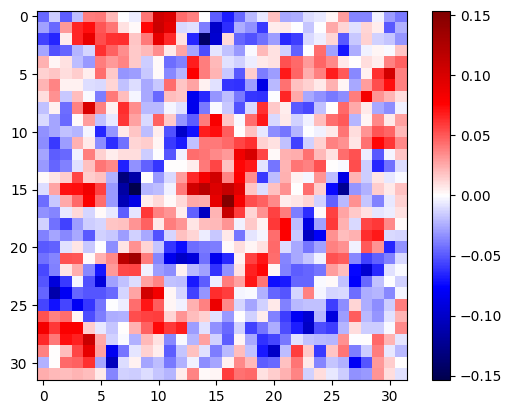

In [548]:
plt.imshow(x.detach(), cmap="seismic", norm=plt.cm.colors.CenteredNorm())
plt.colorbar()

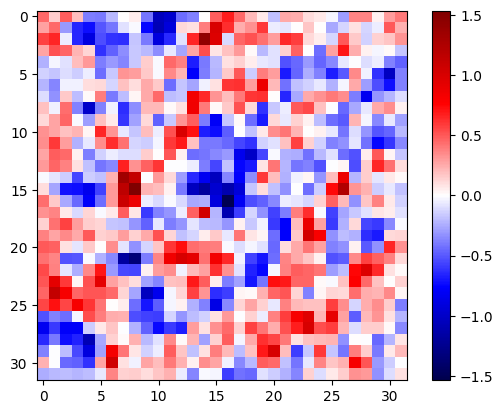

In [549]:
plt.imshow(score_fft, cmap="seismic", norm=plt.cm.colors.CenteredNorm())
plt.colorbar()

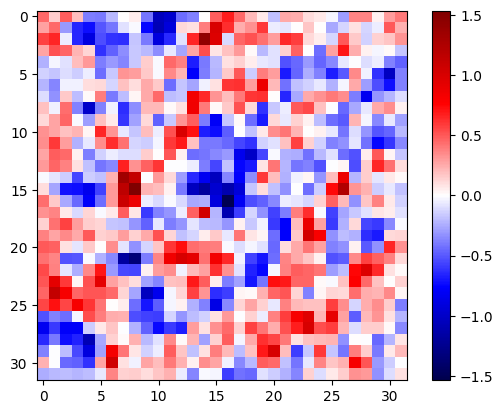

In [550]:
plt.imshow(score_analytic.detach().view(32, 32), cmap="seismic", norm=plt.cm.colors.CenteredNorm())
plt.colorbar()

# Test with flat field noise